In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

In [13]:
image = data.camera()
image = resize(image, (256, 256))  # Resize for faster FFT (optional)
M, N = image.shape  # Get image size

In [ ]:
# Sobel filters
sobel_x = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1],[ 0,  0,  0],[ 1,  2,  1]])

# Proper padding and centering of kernel in spatial domain
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    cy, cx = ph // 2, pw // 2

    padded[cy - kh//2:cy - kh//2 + kh,
           cx - kw//2:cx - kw//2 + kw] = kernel

    return np.fft.fft2(np.fft.ifftshift(padded))

In [30]:
# compute FFT of image
F = np.fft.fft2(image)

# FFT of centered Sobel filters (use the provided function)
cekx = center_embed_kernel(sobel_x, image.shape)
ceky = center_embed_kernel(sobel_y, image.shape)


# Multiply in the frequency domain
dx = F * cekx
dy = F * ceky

In [32]:
# Inverse FFT to get spatial result
domx = np.fft.ifft2(dx).real
domy = np.fft.ifft2(dy).real

# Laplacian spectrum
xspec = np.log(1 + np.abs(dx))
yspec = np.log(1 + np.abs(dy))

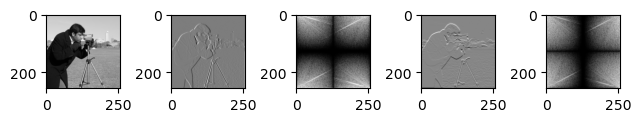

In [34]:
# Plot
plt.subplot(1, 5, 1)
plt.imshow(image, cmap='gray')

plt.subplot(1, 5, 2)
plt.imshow(domx, cmap='gray')

plt.subplot(1, 5, 3)
plt.imshow(xspec, cmap='gray')

plt.subplot(1, 5, 4)
plt.imshow(domy, cmap='gray')

plt.subplot(1, 5, 5)
plt.imshow(yspec, cmap='gray')

plt.tight_layout()
plt.show()